# Incredible work by Gemini. Unfortunately I did not pay attention in linear algebra, but this is helping. I worte the explenations after asking Gemini lots of questions. 

# Matrix Vector Multiplication

Geometric Meaning: 
A vector's endpoint in unstretched space is adjusted to be the endpoint in stretched space. A vector [2, 1] is 2 x units right and one y unit up. When the size of the unit changes, so does the vector endpoint in unstretched space. 

More Detail:
A basis vector is the endpoint of a single unit of x and y space. In unstretched space, the x basis vector is called i and ends at [1, 0]. The y basis vector is called j ends at [0, 1]. These are known as the standarad basis vectors. Each column of the matrix is the shifted endpoint of a basis vector. Every point on the grid is a multiple of these basis vectors. When the matrix is multiplied by a column vector, the i basis vector is scaled by the column vector's x component, and the j basis vector is scaled by the column vector's y component. The two scaled vectors are then summed to find the new endpoint of the transformed column vector. The jupitor notebook makes this easier to picture. Here is another way to think about it: each dimension of the column vector is shrunk or expanded. When the dot product of the x row of the matrix and the column vector is found, the x row of the matrix is the shift of the x dimension over all the basis vectors. When the matrix x values align with the dimensions of the vector, each vector dimension contributes an offset for the output vector's x element. I tried to depict this in the image below. I made it using latex in Excalidraw in Obsidian:

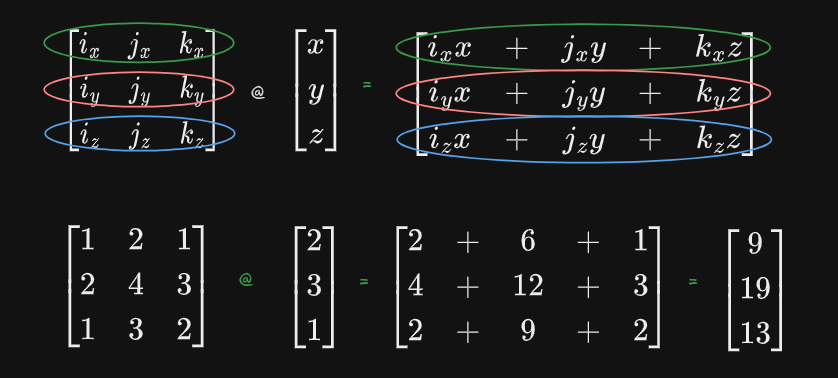

## Vector Matrix Multiplication
Multiplying a vector by a matrix is different. To understand this it helps to understand what it means to muliply a transposed vector by a column vector. A transposed vector is a row vector, and when it is multiplied by a column vector, the result is a scalar score as the components are scaled and then summed. You can think of it like taking a column vector of office supplies S and putting a row vector of the price of each supply P before it (i.e. P dot S). The result of the dot product is the total cost of all suppplies. 

When a row vector is multiplied by a matrix, the result is another row vector. This new row vector will score a column vector in the space scaled by the matrix, meaning you don't need to scale a column vector by the matrix and then use the original score vector. Instead, just take the scaled score vector and multiply it by the unscaled column vector. This is not demonstrated in the script but I think it is worth mentioning.

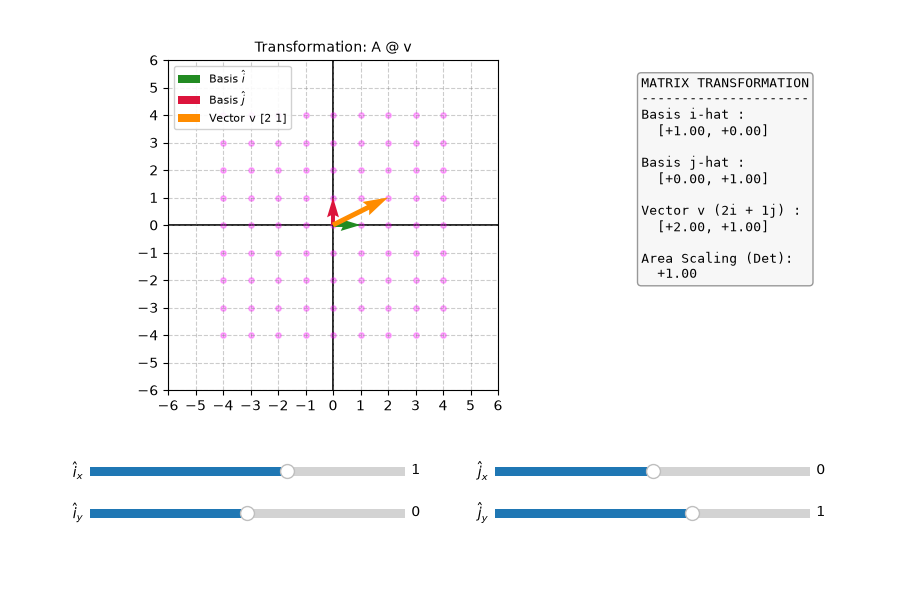

In [ ]:
"""
Interactive Matrix-Vector Multiplication Visualizer

by Gemini

If the sliders don't work, rerun the cell.
"""

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# 1. Base Grid Setup
min_val, max_val = -4, 5
range_values = np.arange(min_val, max_val, 1)
x, y = np.meshgrid(range_values, range_values)
grid = np.vstack([x.flatten(), y.flatten()])
v = np.array([2, 1])  # Input vector v = [x, y]

# 2. Setup Figure & Layout
fig = plt.figure(figsize=(9, 6))

# Main Plot Axes
ax = fig.add_axes([0.08, 0.35, 0.58, 0.55])  

# Text Readout Box Axes (Right side)
ax_info = fig.add_axes([0.70, 0.35, 0.25, 0.55])  
ax_info.axis('off')  # Hide axis lines/ticks for text card

# Initial Matrix A = [[i_x, j_x], [i_y, j_y]]
i_x, i_y = 1.0, 0.0
j_x, j_y = 0.0, 1.0
A = np.array([[i_x, j_x], [i_y, j_y]])

grid_transformed = A @ grid
v_transformed = A @ v

# Setup main plot limits
ticks = np.arange(-6, 7, 1)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.axhline(0, color='black', lw=1.2, zorder=1)
ax.axvline(0, color='black', lw=1.2, zorder=1)
ax.grid(True, linestyle='--', color='gray', alpha=0.4)
ax.set_aspect('equal')

# 3. Plot Initial Artists
scatter = ax.scatter(grid_transformed[0], grid_transformed[1], color='magenta', alpha=0.3, s=15)

quiver_i = ax.quiver(0, 0, A[0, 0], A[1, 0], angles='xy', scale_units='xy', scale=1, 
                     color='forestgreen', width=0.012, zorder=5, label=r'Basis $\hat{i}$')
quiver_j = ax.quiver(0, 0, A[0, 1], A[1, 1], angles='xy', scale_units='xy', scale=1, 
                     color='crimson', width=0.012, zorder=5, label=r'Basis $\hat{j}$')
quiver_v = ax.quiver(0, 0, v_transformed[0], v_transformed[1], angles='xy', scale_units='xy', scale=1, 
                     color='darkorange', width=0.015, zorder=6, label=f'Vector v {v}')

ax.legend(loc='upper left', framealpha=0.9, fontsize=8)

# 4. Text Readout Initialization
info_text = ax_info.text(
    0.05, 0.95, "", 
    transform=ax_info.transAxes, 
    verticalalignment='top', 
    fontsize=9, 
    family='monospace',
    bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8, edgecolor='gray')
)

# 5. Sliders Layout
ax_ix = fig.add_axes([0.10, 0.20, 0.35, 0.03])
ax_iy = fig.add_axes([0.10, 0.13, 0.35, 0.03])
ax_jx = fig.add_axes([0.55, 0.20, 0.35, 0.03])
ax_jy = fig.add_axes([0.55, 0.13, 0.35, 0.03])

slider_ix = Slider(ax_ix, r'$\hat{i}_x$', -4.0, 4.0, valinit=i_x)
slider_iy = Slider(ax_iy, r'$\hat{i}_y$', -4.0, 4.0, valinit=i_y)
slider_jx = Slider(ax_jx, r'$\hat{j}_x$', -4.0, 4.0, valinit=j_x)
slider_jy = Slider(ax_jy, r'$\hat{j}_y$', -4.0, 4.0, valinit=j_y)

# 6. Dynamic Update Function
def update(val):
    new_ix, new_iy = slider_ix.val, slider_iy.val
    new_jx, new_jy = slider_jx.val, slider_jy.val
    
    A_new = np.array([[new_ix, new_jx],
                      [new_iy, new_jy]])

    new_grid = A_new @ grid
    new_v = A_new @ v

    # Update Plot Vectors
    scatter.set_offsets(new_grid.T)
    quiver_i.set_UVC(new_ix, new_iy)
    quiver_j.set_UVC(new_jx, new_jy)
    quiver_v.set_UVC(new_v[0], new_v[1])

    # Update Output Coordinate Readout Text
    readout_str = (
        f"MATRIX TRANSFORMATION\n"
        f"---------------------\n"
        f"Basis i-hat :\n  [{new_ix:+.2f}, {new_iy:+.2f}]\n\n"
        f"Basis j-hat :\n  [{new_jx:+.2f}, {new_jy:+.2f}]\n\n"
        f"Vector v ({v[0]}i + {v[1]}j) :\n  [{new_v[0]:+.2f}, {new_v[1]:+.2f}]\n\n"
        f"Area Scaling (Det):\n  {np.linalg.det(A_new):+.2f}"
    )
    info_text.set_text(readout_str)
    
    ax.set_title(f"Transformation: A @ v", fontsize=10)
    fig.canvas.draw_idle()

# Attach updates to sliders
slider_ix.on_changed(update)
slider_iy.on_changed(update)
slider_jx.on_changed(update)
slider_jy.on_changed(update)

# Initial text render call
update(None)

plt.show()

# Matrix Matrix Multiplication

Geometric Meaning: Space is transformed twice. It's like multiplying a matrix by a vector but this time there is one vector for every spatial dimension.

More Detail: The first step plays out just like matrix vector multiplication. The dot product of the x row of matrix A and the i vector of matrix B produces the first element of the output matrix. All basis vectors (columns) of matrix A contribute a shift along the x axis for the first element of the output. The second element of the output is in the same row as the first element because this is the dot product of the x row of matrix A and the j vector of matrix B. This is the first step but for vector 2 of matrix B. The completed output matrix is space stretched by both matrices. 

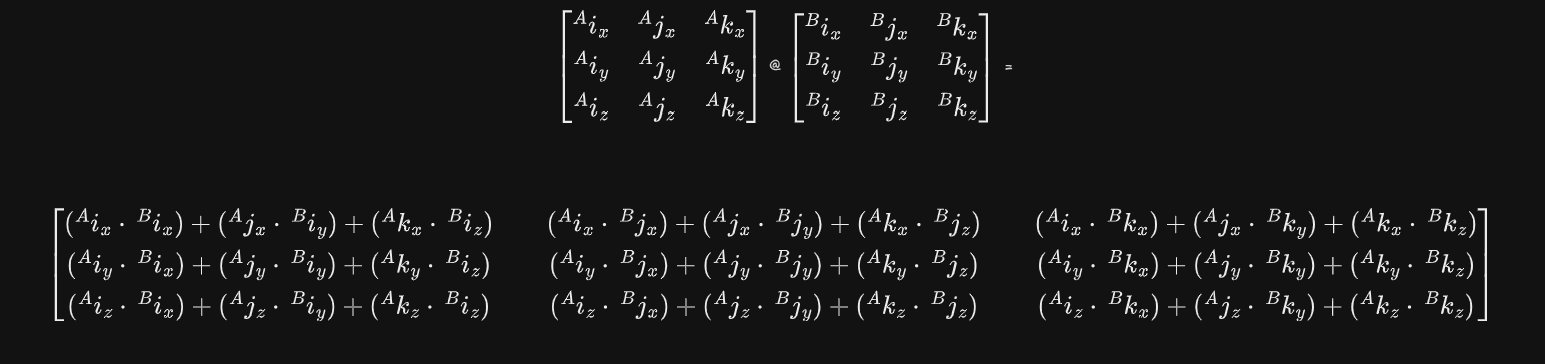

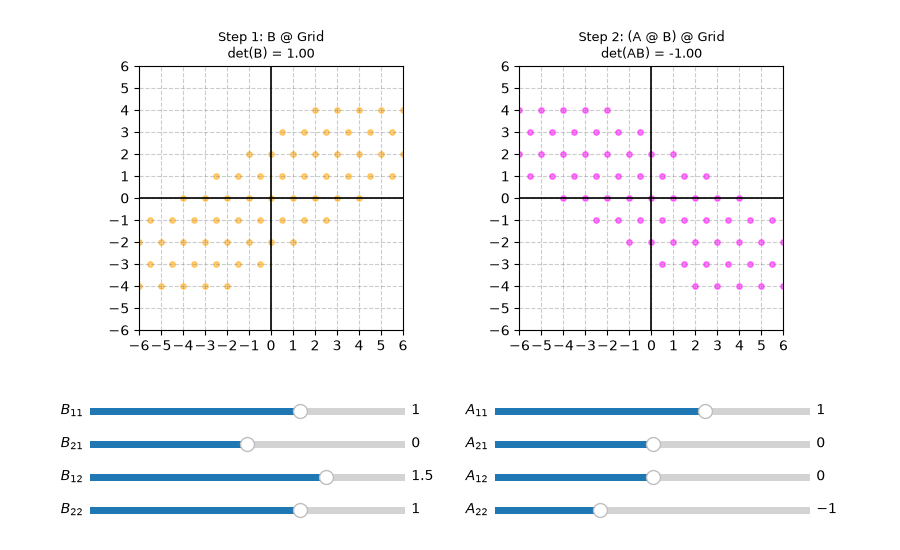

In [ ]:
"""
Interactive Matrix-Matrix Multiplication Visualizer

by Gemini

If the sliders don't work, rerun the cell.
"""

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5.5))
plt.subplots_adjust(bottom=0.4)

# Initial Matrices
b11, b21, b12, b22 = 1.0, 0.0, 1.5, 1.0  # Matrix B (Applied first)
a11, a21, a12, a22 = 1.0, 0.0, 0.0, -1.0 # Matrix A (Applied second)

def format_ax(ax, title):
    ticks = np.arange(-6, 7, 1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')

format_ax(ax1, "Step 1: After B @ Grid")
format_ax(ax2, "Step 2: Composition (A @ B) @ Grid")

scat1 = ax1.scatter([], [], color='orange', alpha=0.5, s=15)
scat2 = ax2.scatter([], [], color='magenta', alpha=0.5, s=15)

# Sliders for Matrix B
ax_b11 = fig.add_axes([0.10, 0.24, 0.35, 0.025])
ax_b21 = fig.add_axes([0.10, 0.18, 0.35, 0.025])
ax_b12 = fig.add_axes([0.10, 0.12, 0.35, 0.025])
ax_b22 = fig.add_axes([0.10, 0.06, 0.35, 0.025])

# Sliders for Matrix A
ax_a11 = fig.add_axes([0.55, 0.24, 0.35, 0.025])
ax_a21 = fig.add_axes([0.55, 0.18, 0.35, 0.025])
ax_a12 = fig.add_axes([0.55, 0.12, 0.35, 0.025])
ax_a22 = fig.add_axes([0.55, 0.06, 0.35, 0.025])

sb11, sb21 = Slider(ax_b11, r'$B_{11}$', -3.0, 3.0, valinit=b11), Slider(ax_b21, r'$B_{21}$', -3.0, 3.0, valinit=b21)
sb12, sb22 = Slider(ax_b12, r'$B_{12}$', -3.0, 3.0, valinit=b12), Slider(ax_b22, r'$B_{22}$', -3.0, 3.0, valinit=b22)

sa11, sa21 = Slider(ax_a11, r'$A_{11}$', -3.0, 3.0, valinit=a11), Slider(ax_a21, r'$A_{21}$', -3.0, 3.0, valinit=a21)
sa12, sa22 = Slider(ax_a12, r'$A_{12}$', -3.0, 3.0, valinit=a12), Slider(ax_a22, r'$A_{22}$', -3.0, 3.0, valinit=a22)

def update(val):
    B = np.array([[sb11.val, sb12.val], [sb21.val, sb22.val]])
    A = np.array([[sa11.val, sa12.val], [sa21.val, sa22.val]])

    g_B = B @ grid
    g_AB = (A @ B) @ grid

    scat1.set_offsets(g_B.T)
    scat2.set_offsets(g_AB.T)

    ax1.set_title(f"Step 1: B @ Grid\ndet(B) = {np.linalg.det(B):.2f}", fontsize=9)
    ax2.set_title(f"Step 2: (A @ B) @ Grid\ndet(AB) = {np.linalg.det(A @ B):.2f}", fontsize=9)
    fig.canvas.draw_idle()

for s in [sb11, sb21, sb12, sb22, sa11, sa21, sa12, sa22]:
    s.on_changed(update)

update(None)
plt.show()

# Matrix Addition

This one is straight forward. Space is shifted by adding each element of A to the element of B at the same position as element A (also called element-wise or entry-wise addition). The matrices must be the same size. The matrices are still the endpoints of the basis vectors, and as such they scale the entire coordinate grid. 

Toggle the check boxes to see the overlay of A and B with the sum matrix. 

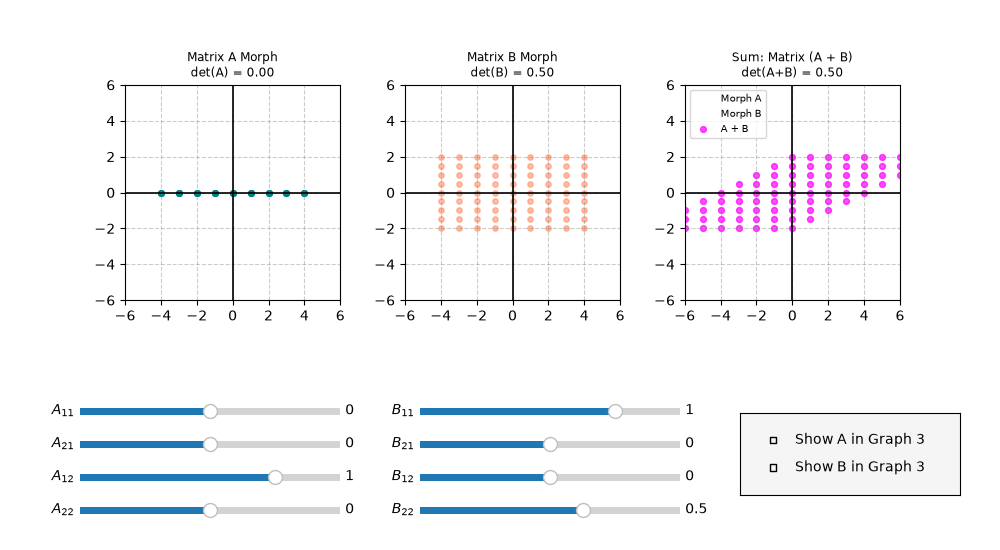

In [ ]:
"""
Interactive Matrix Addition Visualizer (3 Subplots + Toggle Checkbox)

by Gemini

If the sliders don't work, rerun the cell.
"""

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, CheckButtons

# 1. Base Grid Setup
min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

# 2. Figure & Subplots Layout
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5.5))
plt.subplots_adjust(bottom=0.42, wspace=0.3)

# Initial Matrix Values
a11, a21, a12, a22 = 0.0, 0.0, 1.0, 0.0
b11, b21, b12, b22 = 1.0, 0.0, 0.0, 0.5

def format_ax(ax, title):
    ticks = np.arange(-6, 7, 2)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')

format_ax(ax1, "Matrix A Morph")
format_ax(ax2, "Matrix B Morph")
format_ax(ax3, "Sum: Matrix (A + B)")

# Scatter Artists
scat_A_only = ax1.scatter([], [], color='teal', alpha=0.5, s=15)
scat_B_only = ax2.scatter([], [], color='coral', alpha=0.5, s=15)

# Subplot 3 Artists (Set initial visible=False to match the checkbox)
scat_A_overlay = ax3.scatter([], [], color='teal', alpha=0.3, s=12, label='Morph A', visible=False)
scat_B_overlay = ax3.scatter([], [], color='coral', alpha=0.3, s=12, label='Morph B', visible=False)
scat_Sum = ax3.scatter([], [], color='magenta', alpha=0.7, s=18, label='A + B')

ax3.legend(loc='upper left', fontsize=7, framealpha=0.8)

# 3. Sliders Layout
ax_a11 = fig.add_axes([0.08, 0.24, 0.26, 0.025])
ax_a21 = fig.add_axes([0.08, 0.18, 0.26, 0.025])
ax_a12 = fig.add_axes([0.08, 0.12, 0.26, 0.025])
ax_a22 = fig.add_axes([0.08, 0.06, 0.26, 0.025])

ax_b11 = fig.add_axes([0.42, 0.24, 0.26, 0.025])
ax_b21 = fig.add_axes([0.42, 0.18, 0.26, 0.025])
ax_b12 = fig.add_axes([0.42, 0.12, 0.26, 0.025])
ax_b22 = fig.add_axes([0.42, 0.06, 0.26, 0.025])

sa11, sa21 = Slider(ax_a11, r'$A_{11}$', -2.0, 2.0, valinit=a11), Slider(ax_a21, r'$A_{21}$', -2.0, 2.0, valinit=a21)
sa12, sa22 = Slider(ax_a12, r'$A_{12}$', -2.0, 2.0, valinit=a12), Slider(ax_a22, r'$A_{22}$', -2.0, 2.0, valinit=a22)

sb11, sb21 = Slider(ax_b11, r'$B_{11}$', -2.0, 2.0, valinit=b11), Slider(ax_b21, r'$B_{21}$', -2.0, 2.0, valinit=b21)
sb12, sb22 = Slider(ax_b12, r'$B_{12}$', -2.0, 2.0, valinit=b12), Slider(ax_b22, r'$B_{22}$', -2.0, 2.0, valinit=b22)

# 4. Checkbox Layout (Bottom Right)
ax_check = fig.add_axes([0.74, 0.10, 0.22, 0.15], facecolor='whitesmoke')
check = CheckButtons(ax_check, labels=['Show A in Graph 3', 'Show B in Graph 3'], actives=[False, False])

# 5. Dynamic Update Logic
def update(val=None):
    A = np.array([[sa11.val, sa12.val], [sa21.val, sa22.val]])
    B = np.array([[sb11.val, sb12.val], [sb21.val, sb22.val]])

    grid_A = A @ grid
    grid_B = B @ grid
    grid_Sum = (A + B) @ grid

    # Update Scatter Points
    scat_A_only.set_offsets(grid_A.T)
    scat_B_only.set_offsets(grid_B.T)

    scat_A_overlay.set_offsets(grid_A.T)
    scat_B_overlay.set_offsets(grid_B.T)
    scat_Sum.set_offsets(grid_Sum.T)

    # Subplot Titles
    ax1.set_title(f"Matrix A Morph\ndet(A) = {np.linalg.det(A):.2f}", fontsize=8.5)
    ax2.set_title(f"Matrix B Morph\ndet(B) = {np.linalg.det(B):.2f}", fontsize=8.5)
    ax3.set_title(f"Sum: Matrix (A + B)\ndet(A+B) = {np.linalg.det(A + B):.2f}", fontsize=8.5)

    fig.canvas.draw_idle()

def toggle_summands(label=None):
    status = check.get_status()
    scat_A_overlay.set_visible(status[0])
    scat_B_overlay.set_visible(status[1])
    fig.canvas.draw_idle()

# Attach Callbacks
for s in [sa11, sa21, sa12, sa22, sb11, sb21, sb12, sb22]:
    s.on_changed(update)

check.on_clicked(toggle_summands)

# Initial sync calls
update()
toggle_summands()

plt.show()

# Scalar Matrix Multiplication

This one is also straight forward. Every element of the matrix is multiplied by the same scalar, expanding or contracting space by the scalar. Area increases by a factor of the scalar squared. This is uniform case. The non-uniform case involves multipluing the basis vectors and even their elements by varying values. 

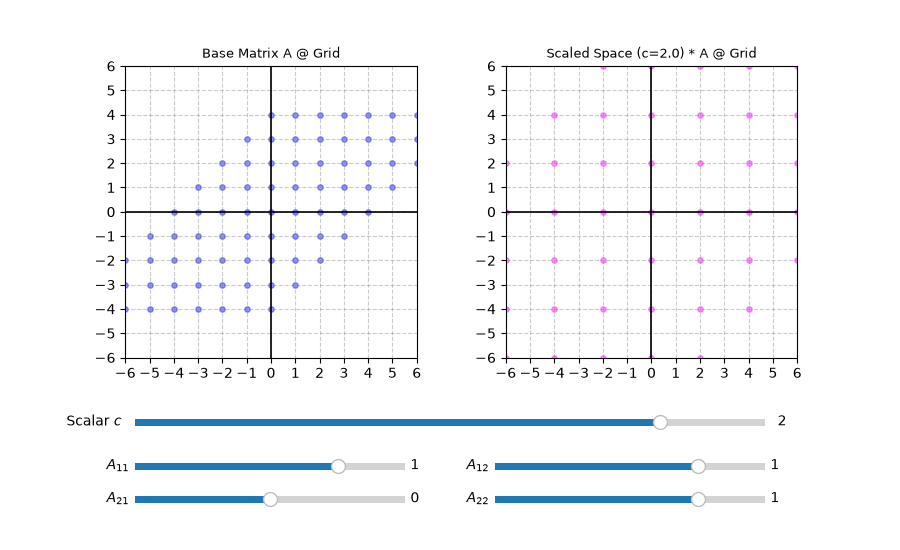

In [ ]:
"""
Interactive Matrix Scalar Multiplication Visualizer

by Gemini

If the sliders don't work, rerun the cell.
"""

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5.5))
plt.subplots_adjust(bottom=0.35)

def format_ax(ax, title):
    ticks = np.arange(-6, 7, 1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')

format_ax(ax1, "Base Morph (Matrix A)")
format_ax(ax2, "Scaled Morph (c * Matrix A)")

scat1 = ax1.scatter([], [], color='blue', alpha=0.4, s=15)
scat2 = ax2.scatter([], [], color='magenta', alpha=0.4, s=15)

# Sliders
ax_c = fig.add_axes([0.15, 0.22, 0.7, 0.025])
ax_a11 = fig.add_axes([0.15, 0.14, 0.3, 0.025])
ax_a21 = fig.add_axes([0.15, 0.08, 0.3, 0.025])
ax_a12 = fig.add_axes([0.55, 0.14, 0.3, 0.025])
ax_a22 = fig.add_axes([0.55, 0.08, 0.3, 0.025])

slider_c = Slider(ax_c, r'Scalar $c$', -3.0, 3.0, valinit=2.0)
sa11, sa21 = Slider(ax_a11, r'$A_{11}$', -2.0, 2.0, valinit=1.0), Slider(ax_a21, r'$A_{21}$', -2.0, 2.0, valinit=0.0)
sa12, sa22 = Slider(ax_a12, r'$A_{12}$', -2.0, 2.0, valinit=1.0), Slider(ax_a22, r'$A_{22}$', -2.0, 2.0, valinit=1.0)

def update(val):
    c = slider_c.val
    A = np.array([[sa11.val, sa12.val], [sa21.val, sa22.val]])

    scat1.set_offsets((A @ grid).T)
    scat2.set_offsets(((c * A) @ grid).T)

    ax1.set_title(f"Base Matrix A @ Grid", fontsize=9)
    ax2.set_title(f"Scaled Space (c={c:.1f}) * A @ Grid", fontsize=9)
    fig.canvas.draw_idle()

for s in [slider_c, sa11, sa21, sa12, sa22]:
    s.on_changed(update)

update(None)
plt.show()

# Matrix Transposition 

Transposing a column vector turns the column into a row. Transposing a row vector turns every column into a row. Transposing a matrix turns every column into a row starting from the left most column. This operation does not change the position of the elements along the diagonal. Instead it switches the position of all other elenments such that [i, j] becomes [j, i]. This is useful for aligning dimensions.

I got Gemini to catalog the major cases for which matrix operations require transposition to align the dimensions. The one I know best is vector matrix multiplication. If vector is a column it must be transposed so that the number of columns matches the number of rows in the matrix. You can try not transforming the vector and instead dot product the column of the vector with the columns of the matrix, but no one does that. Instead the convention is to dot product the row of the transposed vector and the columns of the matrix. 

It helps to remember that the foundational notaion of a matrix is that each column represents a basis vector endpoint in unstretched space. This means that transforming a vector into the stretched space can be accomplished by scaling the basis vectors by the column vector components in any order you want to. You don't need to start with the dot product of the first row and the column vector, but the dot product formula makes it quick and easy. This is even more true when doing matrix matrix multiplication. 

If the basis vectors were rows instead of columns, the dot product would be done with columns and rows instead of rows and columns. Also, if different matrix applications used different multiplication engines such as row by row or column by column, the transpose operator would not be useful. It is the convention to always dot product the rows and columns to keep things consistent, which makes a transpose operator practical in some cases. 

In the graph below, the i_x slider shifts the i_x component for both A and A^T. The same is true for the j_y component. The i_y and j_x sliders behave as expected for matrix A but are swapped for matrix A^T. The i_y slider maps to j_x and the j_x to i_y.  

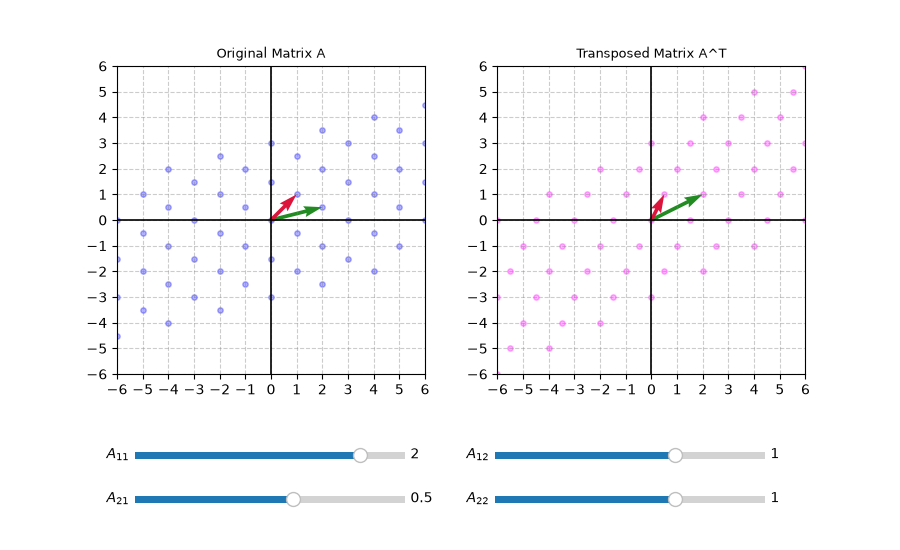

In [ ]:
"""
Interactive Matrix Transposition Visualizer 

by Gemini

If the sliders don't work, rerun the cell.
"""

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5.5))
plt.subplots_adjust(bottom=0.32)

def format_ax(ax, title):
    ticks = np.arange(-6, 7, 1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')

format_ax(ax1, "Original Matrix A")
format_ax(ax2, "Transposed Matrix A^T")

scat1 = ax1.scatter([], [], color='blue', alpha=0.3, s=15)
scat2 = ax2.scatter([], [], color='magenta', alpha=0.3, s=15)

q1_i = ax1.quiver(0, 0, 0, 0, angles='xy', scale_units='xy', scale=1, color='forestgreen', width=0.012)
q1_j = ax1.quiver(0, 0, 0, 0, angles='xy', scale_units='xy', scale=1, color='crimson', width=0.012)

q2_i = ax2.quiver(0, 0, 0, 0, angles='xy', scale_units='xy', scale=1, color='forestgreen', width=0.012)
q2_j = ax2.quiver(0, 0, 0, 0, angles='xy', scale_units='xy', scale=1, color='crimson', width=0.012)

# Sliders
ax_a11, ax_a21 = fig.add_axes([0.15, 0.16, 0.3, 0.025]), fig.add_axes([0.15, 0.08, 0.3, 0.025])
ax_a12, ax_a22 = fig.add_axes([0.55, 0.16, 0.3, 0.025]), fig.add_axes([0.55, 0.08, 0.3, 0.025])

sa11, sa21 = Slider(ax_a11, r'$A_{11}$', -3.0, 3.0, valinit=2.0), Slider(ax_a21, r'$A_{21}$', -3.0, 3.0, valinit=0.5)
sa12, sa22 = Slider(ax_a12, r'$A_{12}$', -3.0, 3.0, valinit=1.0), Slider(ax_a22, r'$A_{22}$', -3.0, 3.0, valinit=1.0)

def update(val):
    A = np.array([[sa11.val, sa12.val], [sa21.val, sa22.val]])
    AT = A.T

    scat1.set_offsets((A @ grid).T)
    scat2.set_offsets((AT @ grid).T)

    q1_i.set_UVC(A[0,0], A[1,0])
    q1_j.set_UVC(A[0,1], A[1,1])

    q2_i.set_UVC(AT[0,0], AT[1,0])
    q2_j.set_UVC(AT[0,1], AT[1,1])

    fig.canvas.draw_idle()

for s in [sa11, sa21, sa12, sa22]:
    s.on_changed(update)

update(None)
plt.show()

# Matrix Determinant 

The determinant of a matrix is the factor by which the area of a square unit of the coordinate grid has changed after stretching space. The formula is 

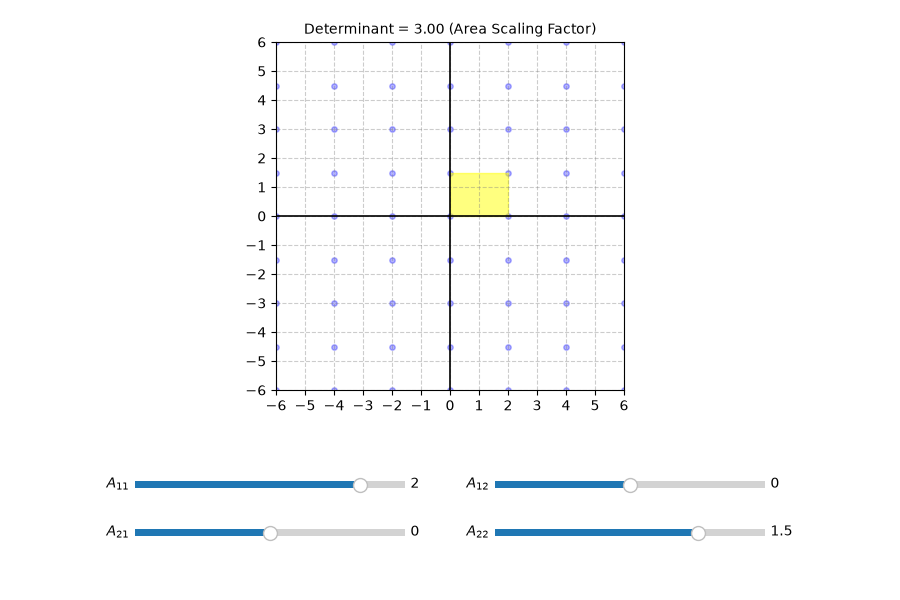

In [ ]:
"""
Interactive Matrix Determinant Visualizer

by Gemini

If the sliders don't work, rerun the cell.
"""

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.patches import Polygon

min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

fig = plt.figure(figsize=(9, 6))
ax = fig.add_axes([0.1, 0.35, 0.8, 0.58])

ticks = np.arange(-6, 7, 1)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.axhline(0, color='black', lw=1.2)
ax.axvline(0, color='black', lw=1.2)
ax.grid(True, linestyle='--', color='gray', alpha=0.4)
ax.set_aspect('equal')

scatter = ax.scatter([], [], color='blue', alpha=0.3, s=15)
poly = Polygon([[0,0], [0,0], [0,0], [0,0]], color='yellow', alpha=0.5, label='Area Scaling Factor')
ax.add_patch(poly)

ax_a11, ax_a21 = fig.add_axes([0.15, 0.18, 0.3, 0.025]), fig.add_axes([0.15, 0.10, 0.3, 0.025])
ax_a12, ax_a22 = fig.add_axes([0.55, 0.18, 0.3, 0.025]), fig.add_axes([0.55, 0.10, 0.3, 0.025])

sa11, sa21 = Slider(ax_a11, r'$A_{11}$', -3.0, 3.0, valinit=2.0), Slider(ax_a21, r'$A_{21}$', -3.0, 3.0, valinit=0.0)
sa12, sa22 = Slider(ax_a12, r'$A_{12}$', -3.0, 3.0, valinit=0.0), Slider(ax_a22, r'$A_{22}$', -3.0, 3.0, valinit=1.5)

def update(val):
    A = np.array([[sa11.val, sa12.val], [sa21.val, sa22.val]])
    scatter.set_offsets((A @ grid).T)

    # Unit square corners transformed
    p1 = np.array([0, 0])
    p2 = A @ np.array([1, 0])
    p3 = A @ np.array([1, 1])
    p4 = A @ np.array([0, 1])
    poly.set_xy([p1, p2, p3, p4])

    det = np.linalg.det(A)
    ax.set_title(f"Determinant = {det:.2f} (Area Scaling Factor)", fontsize=10)
    fig.canvas.draw_idle()

for s in [sa11, sa21, sa12, sa22]:
    s.on_changed(update)

update(None)
plt.show()

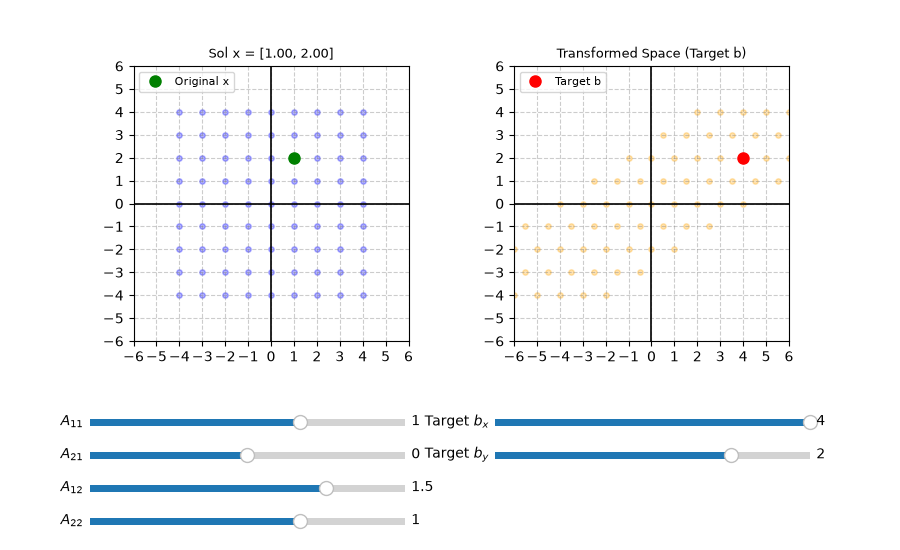

In [7]:
# %%
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5.5))
plt.subplots_adjust(bottom=0.38)

def format_ax(ax, title):
    ticks = np.arange(-6, 7, 1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')

format_ax(ax1, "Original Space (Solution x = A_inv @ b)")
format_ax(ax2, "Transformed Space (Target b)")

scat1 = ax1.scatter([], [], color='blue', alpha=0.3, s=15)
scat2 = ax2.scatter([], [], color='orange', alpha=0.3, s=15)

point_x, = ax1.plot([], [], 'go', markersize=8, label='Original x')
point_b, = ax2.plot([], [], 'ro', markersize=8, label='Target b')
ax1.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper left', fontsize=8)

# Sliders
ax_a11, ax_a21 = fig.add_axes([0.10, 0.22, 0.35, 0.025]), fig.add_axes([0.10, 0.16, 0.35, 0.025])
ax_a12, ax_a22 = fig.add_axes([0.10, 0.10, 0.35, 0.025]), fig.add_axes([0.10, 0.04, 0.35, 0.025])

ax_bx, ax_by = fig.add_axes([0.55, 0.22, 0.35, 0.025]), fig.add_axes([0.55, 0.16, 0.35, 0.025])

sa11, sa21 = Slider(ax_a11, r'$A_{11}$', -3.0, 3.0, valinit=1.0), Slider(ax_a21, r'$A_{21}$', -3.0, 3.0, valinit=0.0)
sa12, sa22 = Slider(ax_a12, r'$A_{12}$', -3.0, 3.0, valinit=1.5), Slider(ax_a22, r'$A_{22}$', -3.0, 3.0, valinit=1.0)

sbx, sby = Slider(ax_bx, r'Target $b_x$', -4.0, 4.0, valinit=4.0), Slider(ax_by, r'Target $b_y$', -4.0, 4.0, valinit=2.0)

def update(val):
    A = np.array([[sa11.val, sa12.val], [sa21.val, sa22.val]])
    b = np.array([sbx.val, sby.val])

    scat1.set_offsets(grid.T)
    scat2.set_offsets((A @ grid).T)

    det = np.linalg.det(A)
    if abs(det) > 1e-4:
        A_inv = np.linalg.inv(A)
        x_sol = A_inv @ b
        point_x.set_data([x_sol[0]], [x_sol[1]])
        ax1.set_title(f"Sol x = [{x_sol[0]:.2f}, {x_sol[1]:.2f}]", fontsize=9)
    else:
        ax1.set_title("Matrix Singular! No Unique Inverse", fontsize=9)

    point_b.set_data([b[0]], [b[1]])
    fig.canvas.draw_idle()

for s in [sa11, sa21, sa12, sa22, sbx, sby]:
    s.on_changed(update)

update(None)
plt.show()

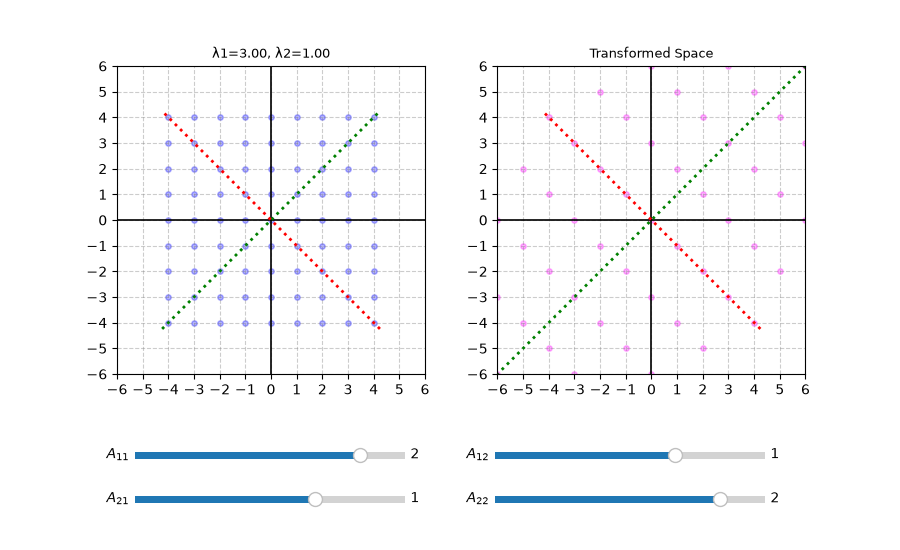

In [9]:
# %%
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5.5))
plt.subplots_adjust(bottom=0.32)

def format_ax(ax, title):
    ticks = np.arange(-6, 7, 1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')

format_ax(ax1, "Original Space + Eigen-Axes")
format_ax(ax2, "Transformed Space")

scat1 = ax1.scatter([], [], color='blue', alpha=0.3, s=15)
scat2 = ax2.scatter([], [], color='magenta', alpha=0.3, s=15)

line1_a, = ax1.plot([], [], 'g:', lw=2)
line2_a, = ax1.plot([], [], 'r:', lw=2)
line1_b, = ax2.plot([], [], 'g:', lw=2)
line2_b, = ax2.plot([], [], 'r:', lw=2)

ax_a11, ax_a21 = fig.add_axes([0.15, 0.16, 0.3, 0.025]), fig.add_axes([0.15, 0.08, 0.3, 0.025])
ax_a12, ax_a22 = fig.add_axes([0.55, 0.16, 0.3, 0.025]), fig.add_axes([0.55, 0.08, 0.3, 0.025])

sa11, sa21 = Slider(ax_a11, r'$A_{11}$', -3.0, 3.0, valinit=2.0), Slider(ax_a21, r'$A_{21}$', -3.0, 3.0, valinit=1.0)
sa12, sa22 = Slider(ax_a12, r'$A_{12}$', -3.0, 3.0, valinit=1.0), Slider(ax_a22, r'$A_{22}$', -3.0, 3.0, valinit=2.0)

def update(val):
    A = np.array([[sa11.val, sa12.val], [sa21.val, sa22.val]])
    
    scat1.set_offsets(grid.T)
    scat2.set_offsets((A @ grid).T)

    evals, evecs = np.linalg.eig(A)
    t = np.linspace(-6, 6, 100)

    if np.isrealobj(evals):
        v1, v2 = evecs[:, 0], evecs[:, 1]
        line1_a.set_data(t * v1[0], t * v1[1])
        line2_a.set_data(t * v2[0], t * v2[1])

        v1_t, v2_t = A @ v1, A @ v2
        line1_b.set_data(t * v1_t[0], t * v1_t[1])
        line2_b.set_data(t * v2_t[0], t * v2_t[1])

        ax1.set_title(f"λ1={evals[0].real:.2f}, λ2={evals[1].real:.2f}", fontsize=9)

    fig.canvas.draw_idle()

for s in [sa11, sa21, sa12, sa22]:
    s.on_changed(update)

update(None)
plt.show()

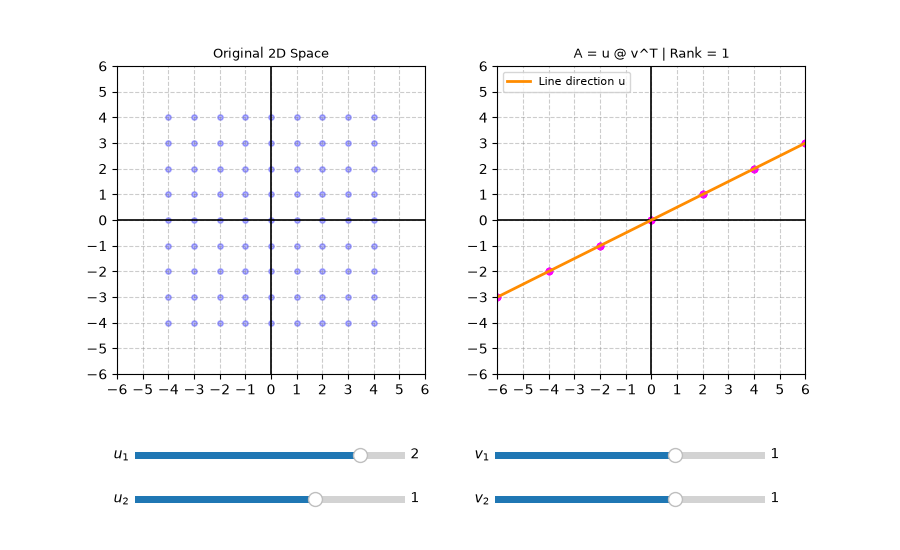

In [8]:
# %%
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

min_val, max_val = -4, 5
x, y = np.meshgrid(np.arange(min_val, max_val, 1), np.arange(min_val, max_val, 1))
grid = np.vstack([x.flatten(), y.flatten()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5.5))
plt.subplots_adjust(bottom=0.32)

def format_ax(ax, title):
    ticks = np.arange(-6, 7, 1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(0, color='black', lw=1.2)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')

format_ax(ax1, "Original 2D Space")
format_ax(ax2, "Outer Product Morph (Rank-1 Line)")

scat1 = ax1.scatter([], [], color='blue', alpha=0.3, s=15)
scat2 = ax2.scatter([], [], color='magenta', alpha=0.6, s=20)
line_u, = ax2.plot([], [], color='darkorange', lw=2, label='Line direction u')
ax2.legend(loc='upper left', fontsize=8)

# Sliders for u and v vectors
ax_u1, ax_u2 = fig.add_axes([0.15, 0.16, 0.3, 0.025]), fig.add_axes([0.15, 0.08, 0.3, 0.025])
ax_v1, ax_v2 = fig.add_axes([0.55, 0.16, 0.3, 0.025]), fig.add_axes([0.55, 0.08, 0.3, 0.025])

su1, su2 = Slider(ax_u1, r'$u_1$', -3.0, 3.0, valinit=2.0), Slider(ax_u2, r'$u_2$', -3.0, 3.0, valinit=1.0)
sv1, sv2 = Slider(ax_v1, r'$v_1$', -3.0, 3.0, valinit=1.0), Slider(ax_v2, r'$v_2$', -3.0, 3.0, valinit=1.0)

def update(val):
    u = np.array([su1.val, su2.val])
    v = np.array([sv1.val, sv2.val])
    
    A_outer = np.outer(u, v)

    scat1.set_offsets(grid.T)
    scat2.set_offsets((A_outer @ grid).T)

    t = np.linspace(-6, 6, 100)
    line_u.set_data(t * u[0], t * u[1])

    ax2.set_title(f"A = u @ v^T | Rank = 1", fontsize=9)
    fig.canvas.draw_idle()

for s in [su1, su2, sv1, sv2]:
    s.on_changed(update)

update(None)
plt.show()